In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [4]:
train_df = pd.read_csv('../data/raw/train.csv')
test_df = pd.read_csv('../data/raw/test.csv')

train_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [5]:
print(train_df.shape)
print(test_df.shape)

(891, 12)
(418, 11)


# EDA

In [6]:
train_df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [7]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
train_df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [9]:
train_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
train_df.nunique().sort_values()

Survived         2
Sex              2
Pclass           3
Embarked         3
SibSp            7
Parch            7
Age             88
Cabin          147
Fare           248
Ticket         681
PassengerId    891
Name           891
dtype: int64

In [11]:
train_df.Survived.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [12]:
train_df[['Pclass', 'Survived']].groupby(['Pclass'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [13]:
train_df[["Sex", "Survived"]].groupby(['Sex'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [14]:
train_df[["SibSp", "Survived"]].groupby(['SibSp'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [15]:
train_df[["Parch", "Survived"]].groupby(['Parch'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


<Figure size 1200x400 with 0 Axes>

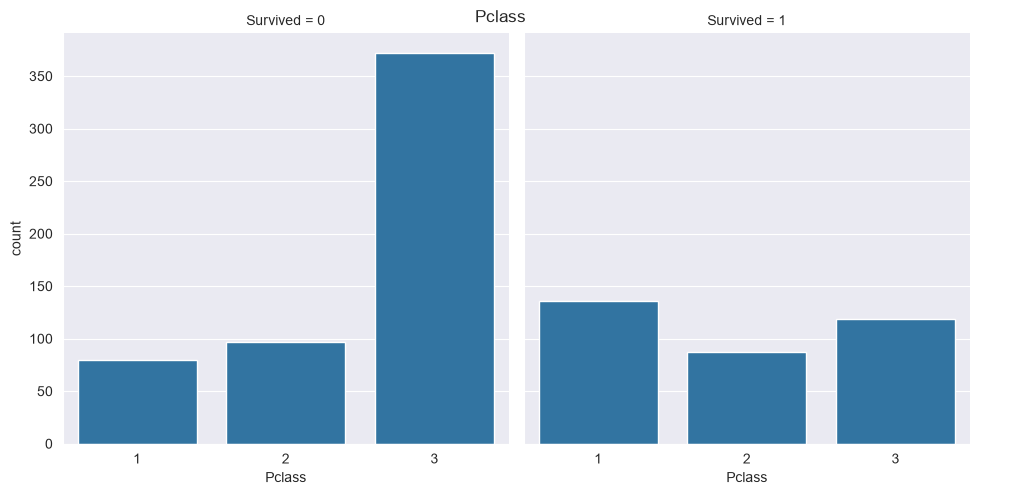

<Figure size 1200x400 with 0 Axes>

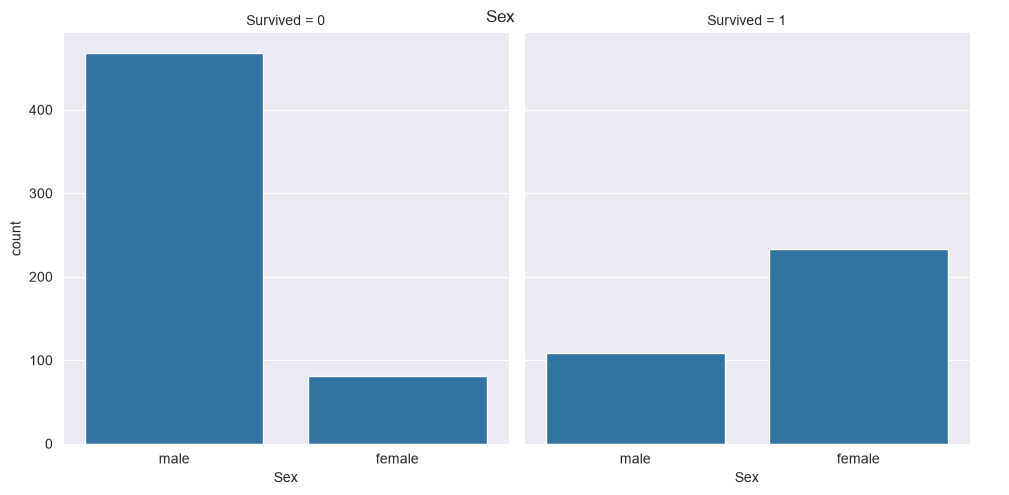

<Figure size 1200x400 with 0 Axes>

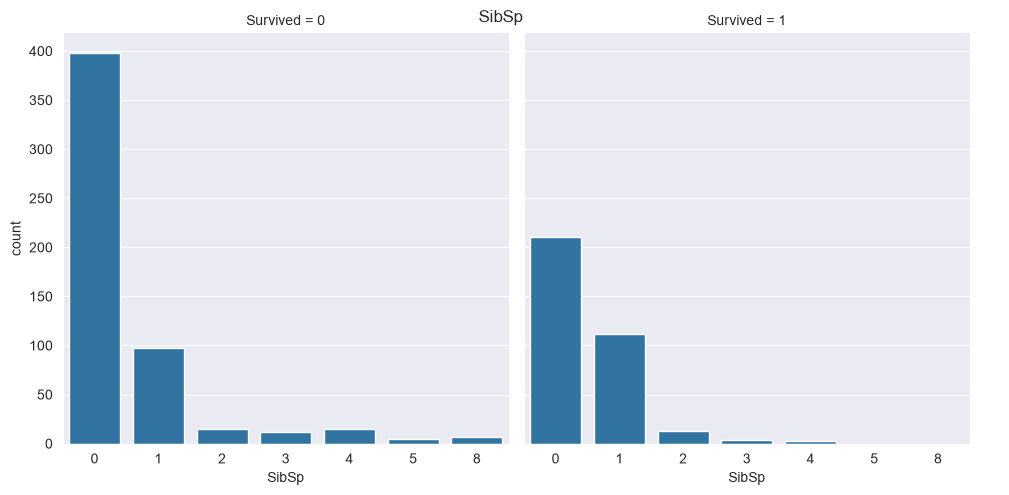

<Figure size 1200x400 with 0 Axes>

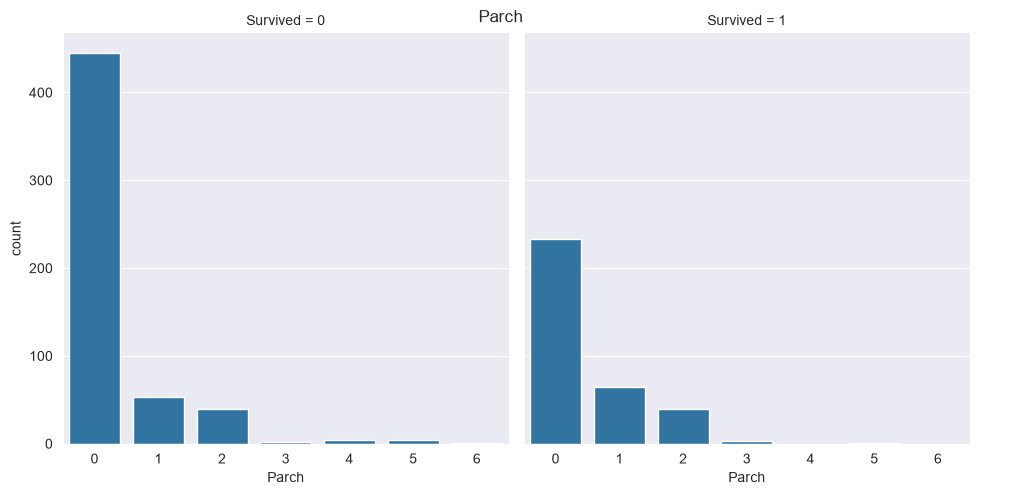

<Figure size 1200x400 with 0 Axes>

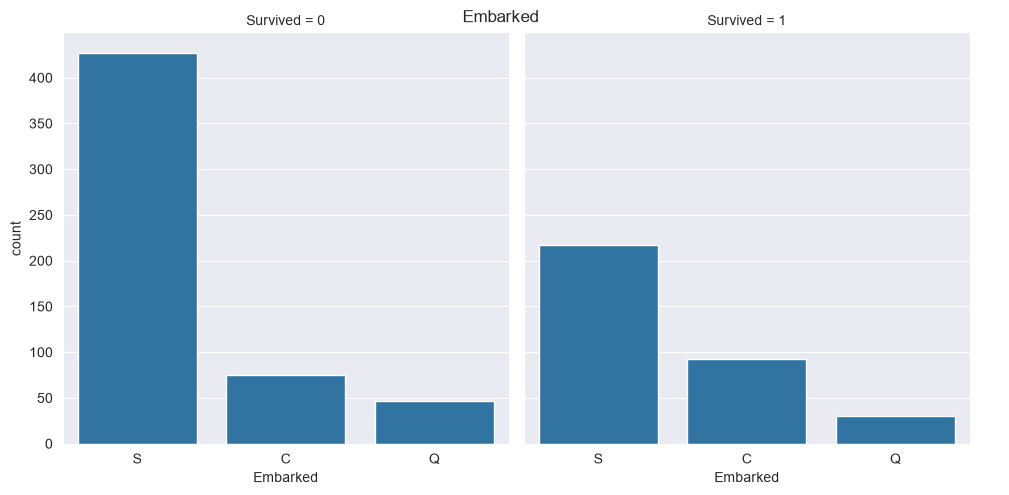

In [16]:
for col in train_df.columns.to_list():
    if train_df[col].nunique() < 8 and col != 'Survived':
        plt.figure(figsize=(12, 4))
        g = sns.catplot(data=train_df, x=col, col='Survived', kind='count')
        g.tight_layout()
        g.figure.suptitle(col)

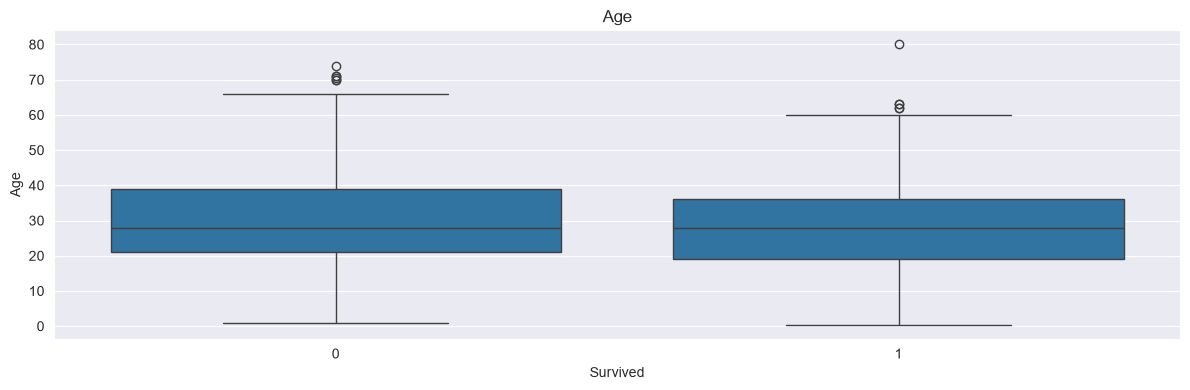

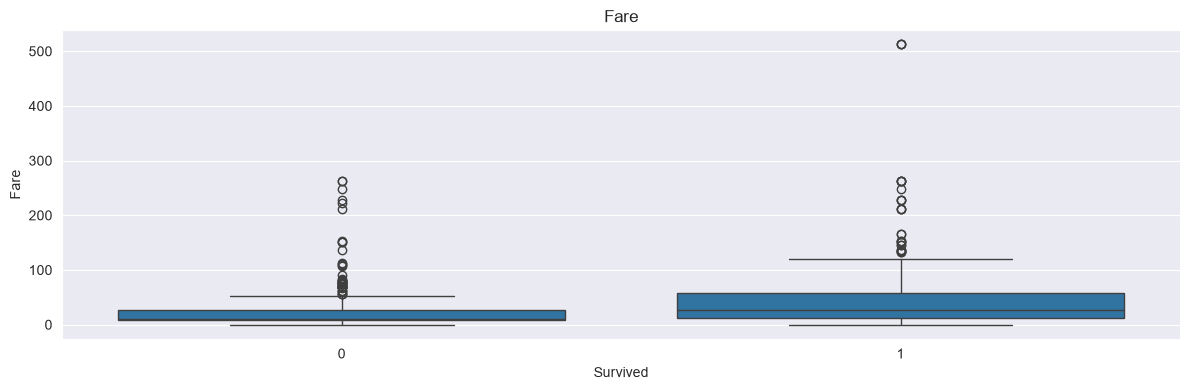

In [17]:
for col in ['Age', 'Fare']:
    plt.figure(figsize=(12, 4))
    sns.boxplot(data=train_df, x='Survived', y=col)
    plt.title(col)
    plt.tight_layout()

In [18]:
# Гипотеза, что кабины указаны для первого класса и что это будет хороший признак
train_df['is_cabin'] = train_df.Cabin.notna()

<Figure size 1200x400 with 0 Axes>

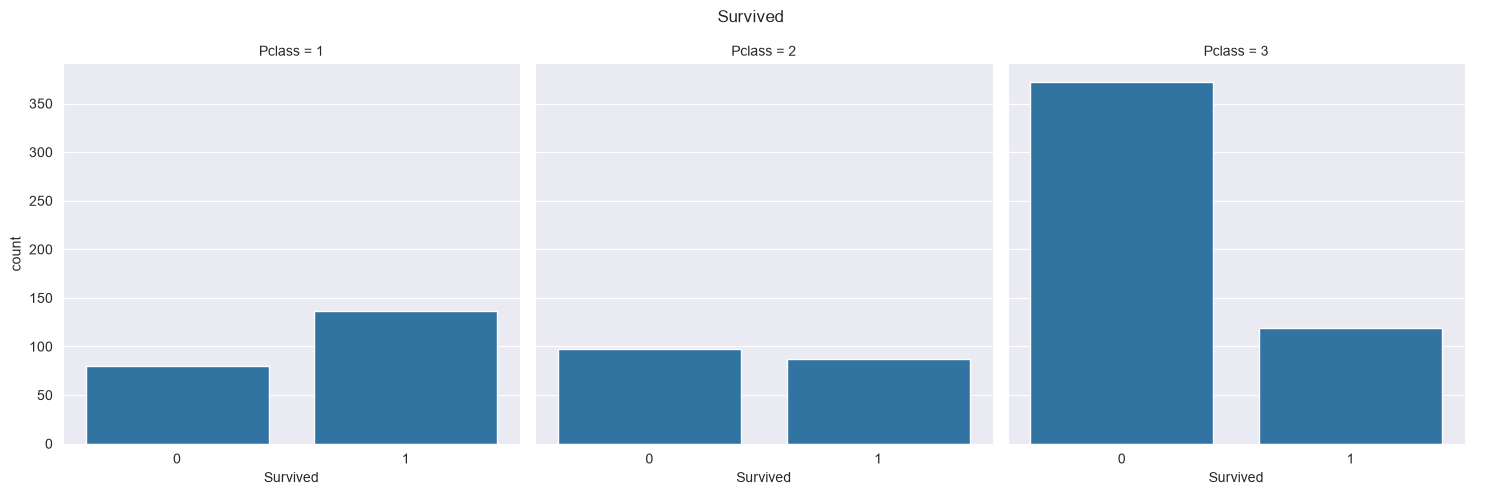

<Figure size 1200x400 with 0 Axes>

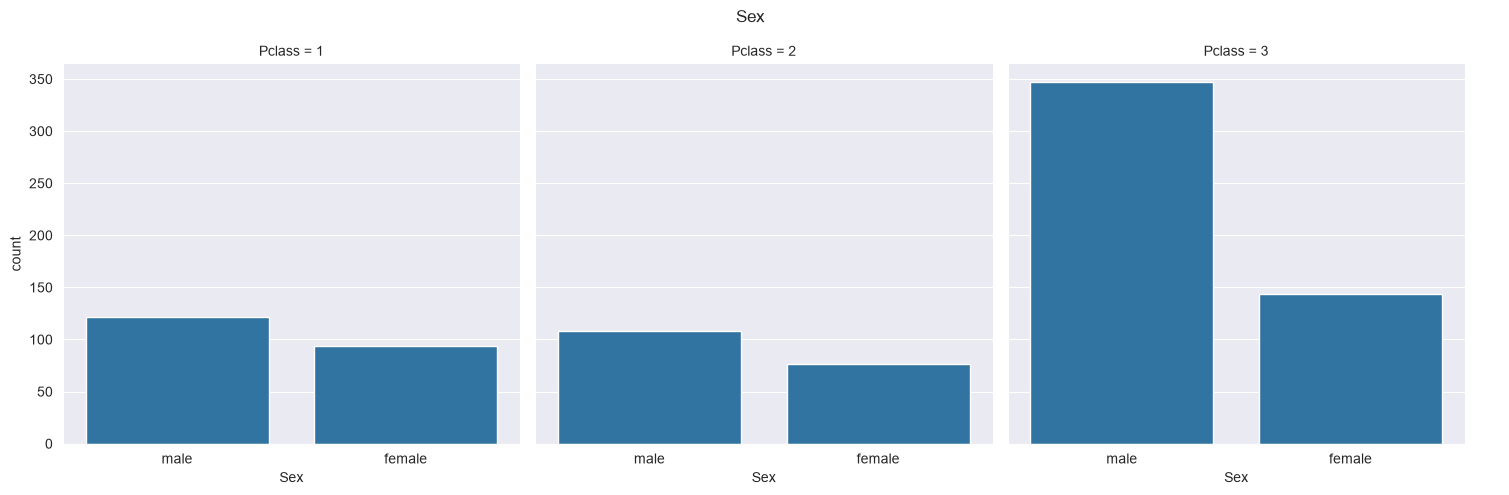

<Figure size 1200x400 with 0 Axes>

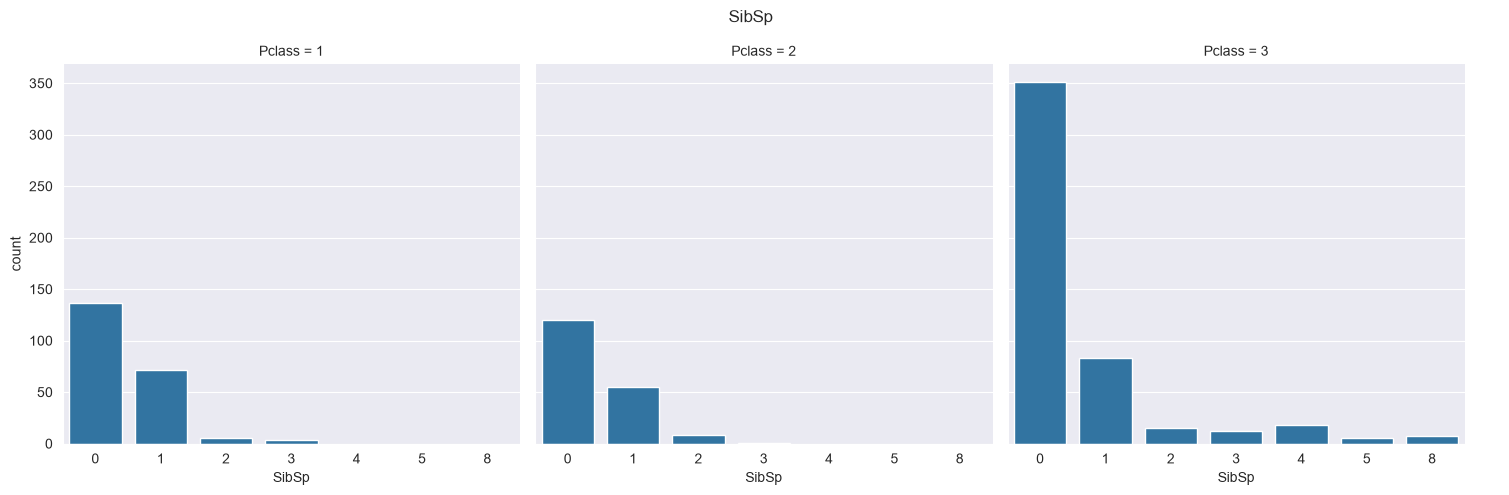

<Figure size 1200x400 with 0 Axes>

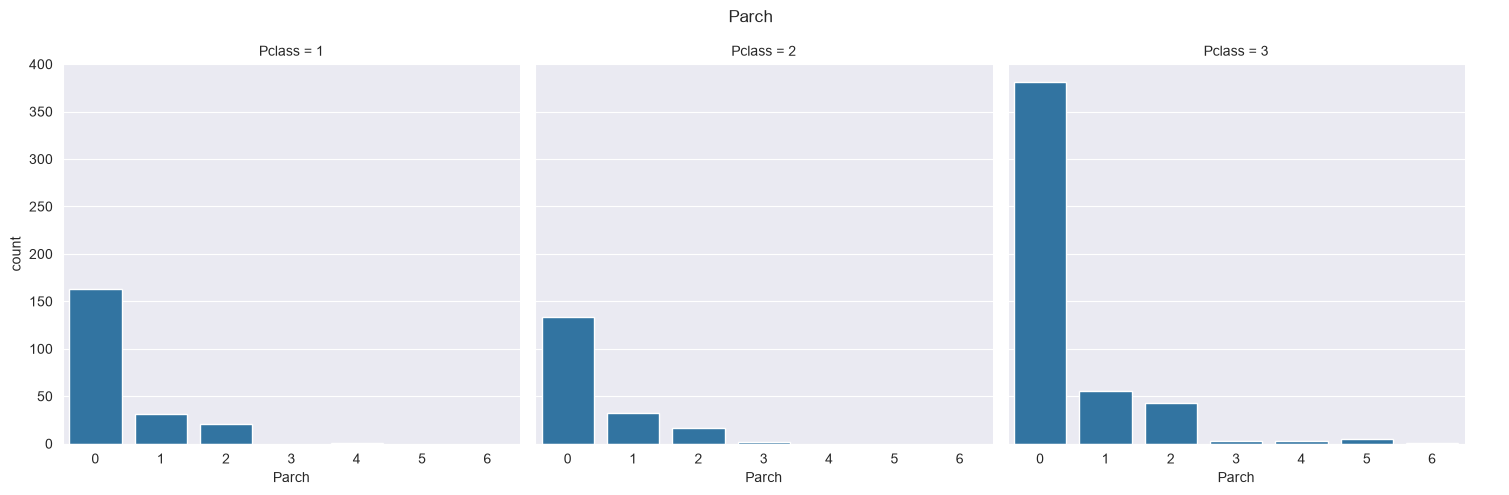

<Figure size 1200x400 with 0 Axes>

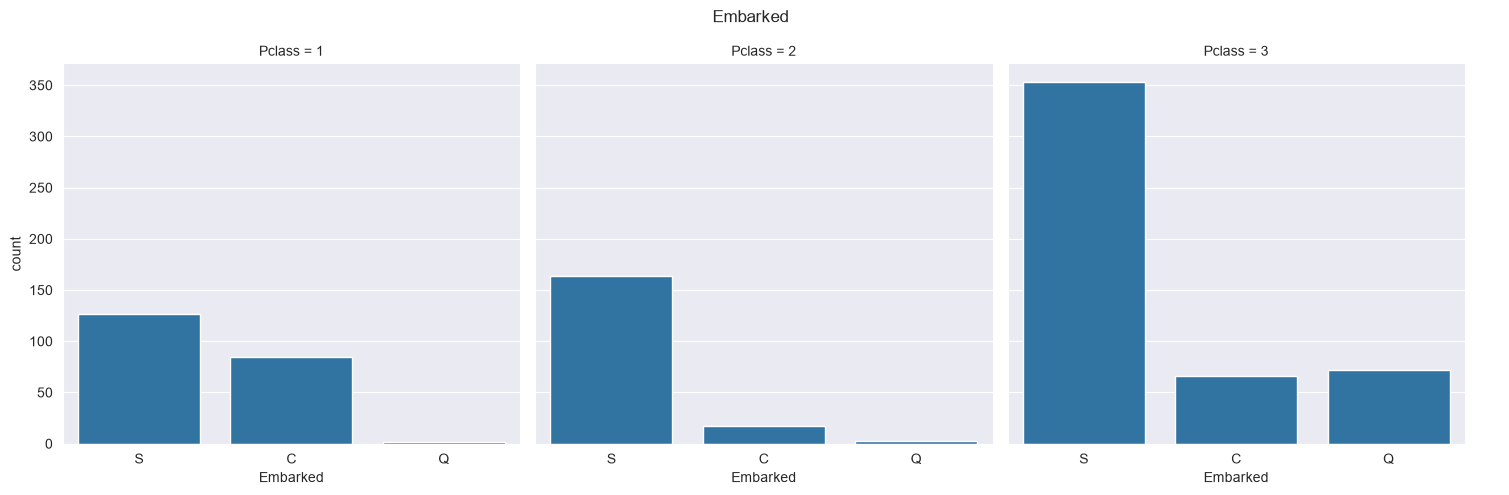

<Figure size 1200x400 with 0 Axes>

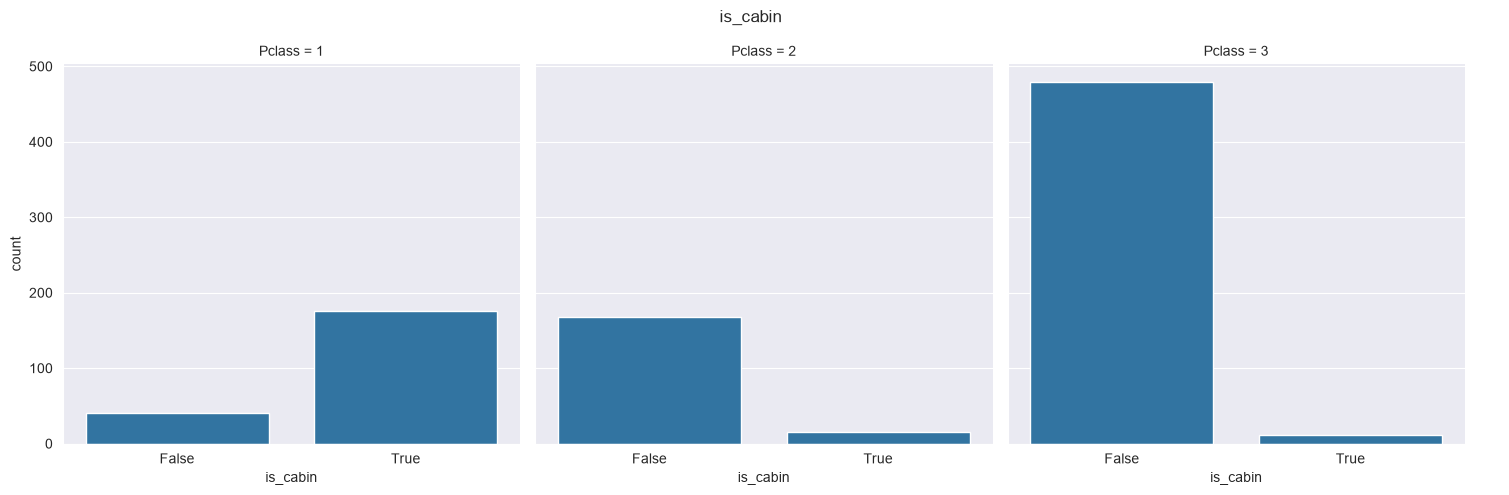

In [19]:
# В зависимости от класса билета (категориальные)
for col in train_df.columns.to_list():
    if train_df[col].nunique() < 8 and col != 'Pclass':
        plt.figure(figsize=(12, 4))
        g = sns.catplot(data=train_df, x=col, col='Pclass', kind='count')
        g.figure.suptitle(col)
        g.tight_layout()

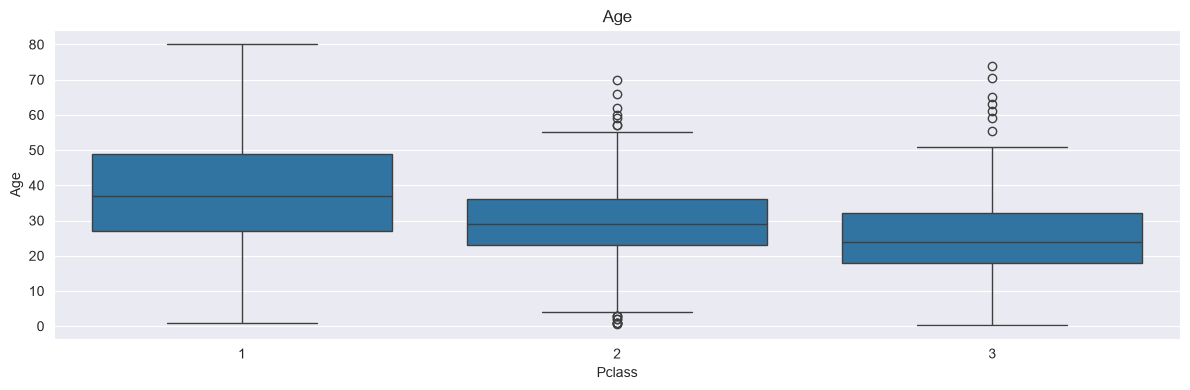

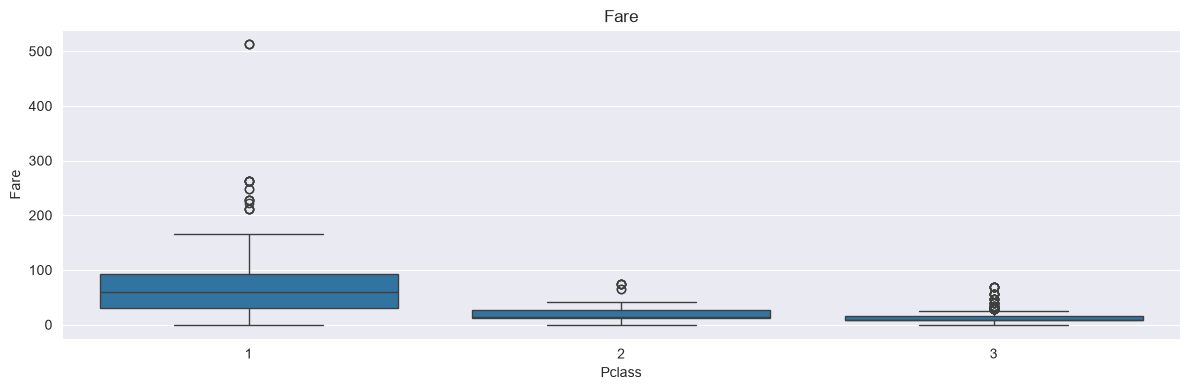

In [20]:
# В зависимости от класса билета (числовые)
for col in ['Age', 'Fare']:
    plt.figure(figsize=(12, 4))
    sns.boxplot(data=train_df, x='Pclass', y=col)
    plt.title(col)
    plt.tight_layout()

In [21]:
train_df['Title'] = train_df.Name.str.extract(r',\s*([^\.]+)\.')
train_df['Title'] = train_df['Title'].where(train_df['Title'].map(train_df['Title'].value_counts()) > 10, 'Rare')
train_df['Title'].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

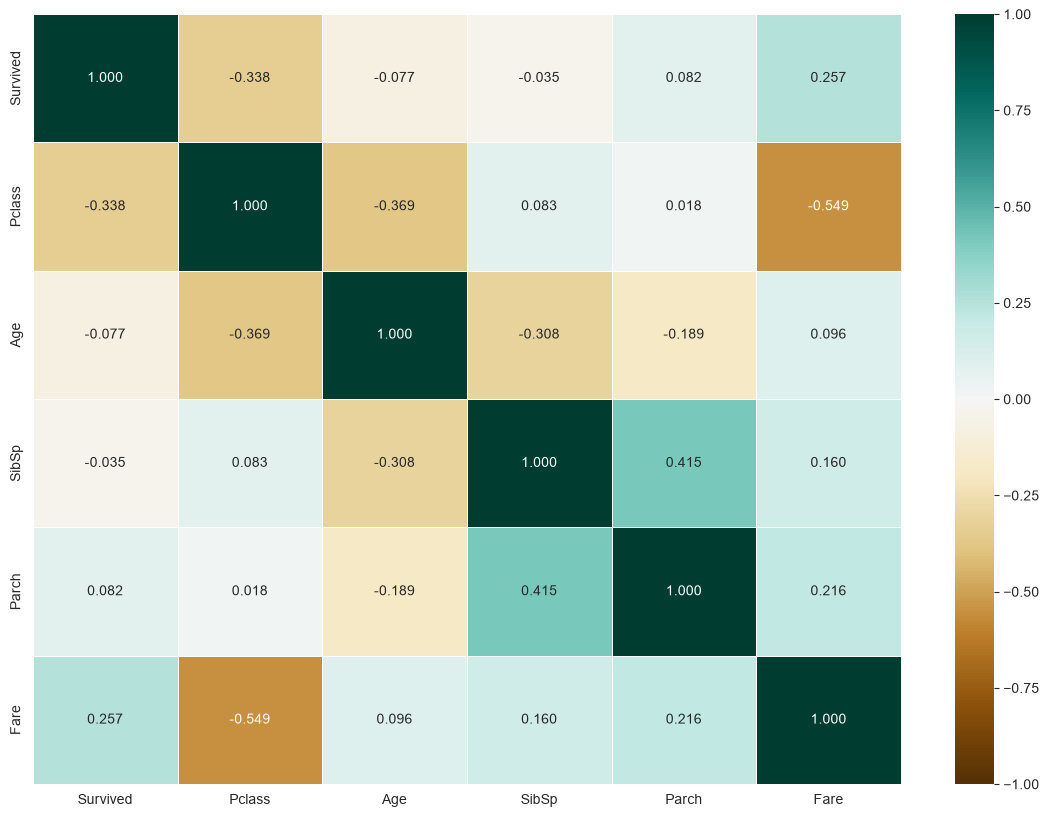

In [22]:
correlation = train_df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation,
    annot=True,
    cmap='BrBG',
    linewidths=0.5,
    vmax=1,
    vmin=-1,
    fmt=".3f"
)
plt.show()

# Modeling

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

In [25]:
def evaluate(model_pipeline: Pipeline, X, y, cv, fit_params=None):

    fit_params = fit_params or {}

    scores = cross_validate(
        model_pipeline,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        params=fit_params,
    )

    return {
        "model": model_pipeline[1],
        "mean_accuracy": scores["test_score"].mean(),
        "std_accuracy": scores["test_score"].std(),
        "fold_scores": scores["test_score"],
    }

In [26]:
numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
]

features = [*numeric_features, *categorical_features]

In [27]:
X = train_df[features]
y = train_df['Survived']

In [28]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=0,
)

## Baseline (log-reg)

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

In [30]:
pipeline_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000)),
])

results_lr = evaluate(pipeline_lr, X, y, cv)

print(results_lr['model'])
print(f'Accuracy: {results_lr['mean_accuracy']:.3f}')

LogisticRegression(max_iter=1000)
Accuracy: 0.796


## Catboost

In [31]:
def fill_categorical_missing(X):
    X = X.copy()
    X[categorical_features] = X[categorical_features].fillna("Missing")
    return X

In [32]:
from sklearn.preprocessing import FunctionTransformer

preprocessor_catboost = FunctionTransformer(
    fill_categorical_missing
)

In [33]:
model_catboost = CatBoostClassifier(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    verbose=False,
    random_seed=0,
)

pipeline_catboost = Pipeline([
    ("preprocessor", preprocessor_catboost),
    ("classifier", model_catboost),
])

results_catboost = evaluate(
    model_pipeline=pipeline_catboost,
    X=X,
    y=y,
    cv=cv,
    fit_params={"classifier__cat_features": categorical_features}
)

print(results_catboost['model'])
print(f'Accuracy: {results_catboost['mean_accuracy']:.3f}')

CatBoostClassifier(depth=6, iterations=500, learning_rate=0.03, loss_function='Logloss', random_seed=0, verbose=False)
Accuracy: 0.825
